# The portfolio

What the book looks like before any model is fitted to it: 48.8 million loans,
$10.5 trillion originated, 2.88 billion loan-months of history.

Everything shown here is computed in `creditsurv.portfolio` and plotted by
`creditsurv.reporting.charts` — this notebook calls those and shows the result.
The narrative version with the numbers written out is
[`docs/portfolio.md`](../docs/portfolio.md).


In [1]:
import pandas as pd

from creditsurv.data.fred import load_macro_panel
from creditsurv.portfolio import (
    covariate_evolution,
    origination_mix,
    originations_by_period,
    outstanding_by_period,
)

pd.set_option("display.width", 140)
macro = load_macro_panel()
print(f"macro: {len(macro)} months, {macro.index.min()} to {macro.index.max()}")

macro: 330 months, 1999-01 to 2026-06


## New lending

The US mortgage market's own history. Four distinct lending regimes in one panel,
which is the argument for time-varying covariates rather than a vintage dummy.


In [2]:
lending = originations_by_period()
print(f"{int(lending['loans'].sum()):,} loans, ${lending['amount'].sum() / 1e12:.2f}tn originated")

by_year = (
    lending.set_index("period")
    .resample("Y")
    .agg({"loans": "sum", "amount": "sum", "mean_score": "mean", "mean_rate": "mean"})
)
by_year.assign(
    loans=(by_year["loans"] / 1e6).round(2),
    amount=(by_year["amount"] / 1e9).round(0),
).rename(columns={"loans": "loans (m)", "amount": "amount ($bn)"}).round(1).tail(12)

48,827,197 loans, $10.51tn originated


,loans (m),amount ($bn),mean_score,mean_rate
period,,,,
2015,1.5,327.0,749.9,4.0
2016,1.6,372.0,748.4,3.8
2017,1.5,341.0,745.7,4.1
2018,1.3,310.0,745.9,4.6
2019,1.6,409.0,748.7,4.4
2020,3.4,975.0,756.7,3.4
2021,4.4,1272.0,753.0,2.9
2022,2.0,588.0,743.9,4.5
2023,0.9,294.0,748.8,6.6


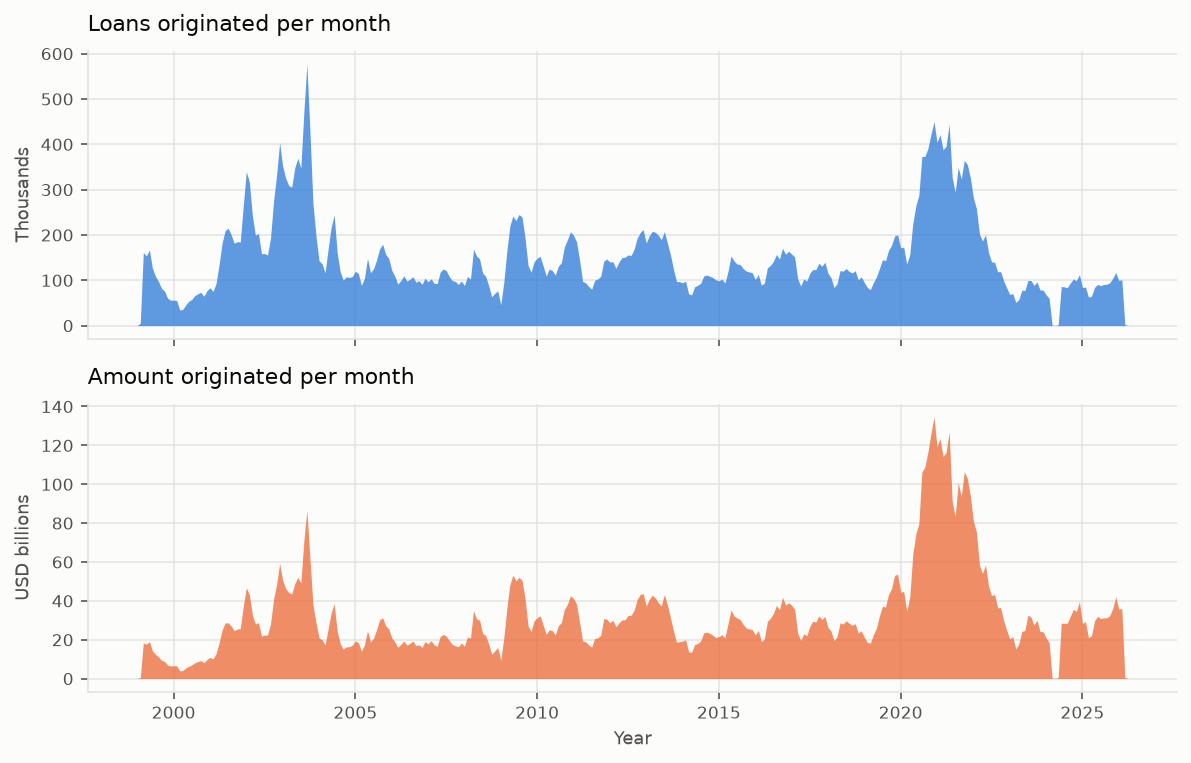

In [3]:
from pathlib import Path

from IPython.display import Image

from creditsurv.reporting import charts

figures = Path("../docs/reports/figures")
figures.mkdir(parents=True, exist_ok=True)
charts.new_lending(lending, figures / "new_lending.png")


Image(str(figures / "new_lending.png"))

## The book outstanding

Contracts and balance do not peak together: the same balance is carried by fewer,
larger loans over time.


peak 13,220,705 contracts, $3.01tn


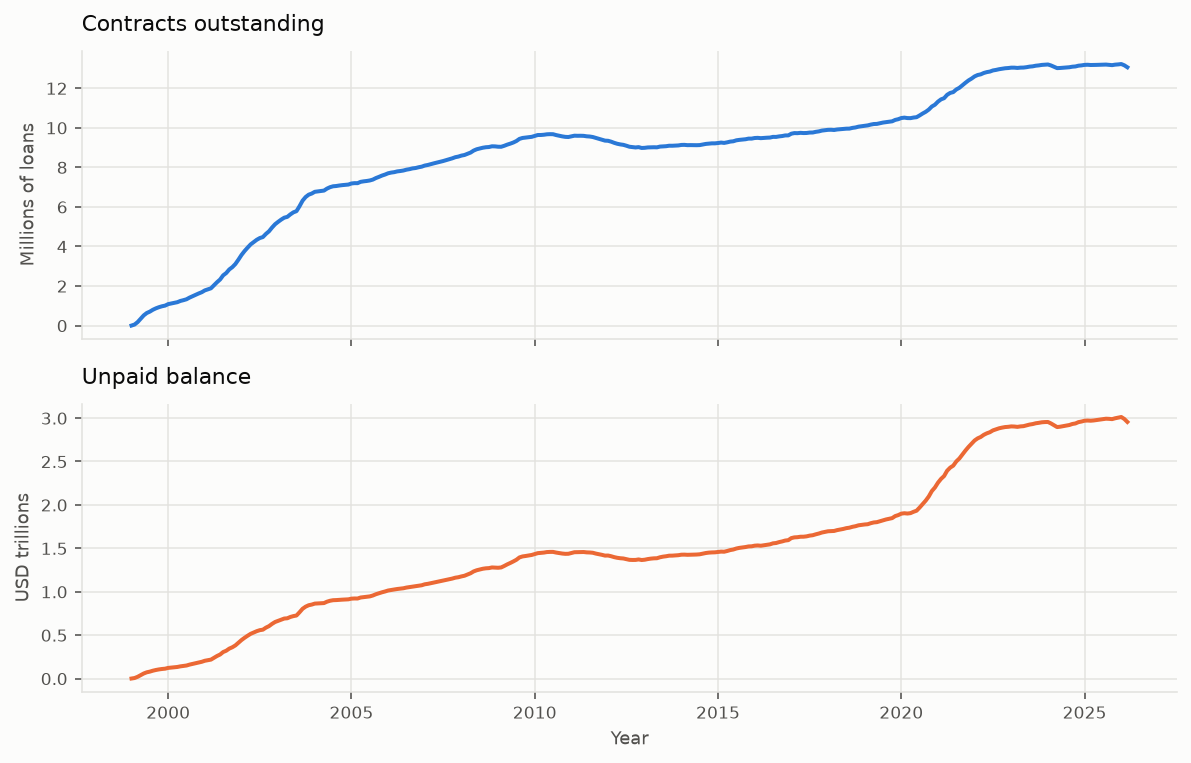

In [4]:
outstanding = outstanding_by_period()
print(
    f"peak {int(outstanding['contracts'].max()):,} contracts, "
    f"${outstanding['balance'].max() / 1e12:.2f}tn"
)
charts.outstanding_book(outstanding, figures / "outstanding_book.png")
Image(str(figures / "outstanding_book.png"))

## What was written, and when

A mix that moves is the reason a model fitted on one decade can mislead about
another.


In [5]:
mix = origination_mix("purpose")
wide = mix.pivot(index="year", columns="level", values="share")
(wide * 100).round(1).loc[[2003, 2008, 2012, 2021]]

level,purchase,refinance_cashout,refinance_rate_term
year,,,
2003,14.2,27.7,58.1
2008,39.2,34.0,26.8
2012,17.1,15.3,67.6
2021,31.7,25.1,43.2


### The finding this view produced

`channel` cannot be used at four levels, and only the time series shows why.


In [6]:
channel = origination_mix("channel").pivot(index="year", columns="level", values="share")
(channel * 100).round(1).loc[[1999, 2003, 2007, 2008, 2009, 2012, 2021]]

level,retail,third_party
year,,
1999,53.8,46.2
2003,58.1,41.9
2007,44.8,55.2
2008,50.4,49.6
2009,58.2,41.8
2012,66.8,33.2
2021,57.9,42.1


Until 2008 roughly half of originations are coded `T` — third-party, not otherwise
specified — and broker and correspondent are near zero. From 2009 `T` vanishes and
those two absorb it exactly.

**That is a change in how the field was coded, not in how loans were sold.** A model
given the four levels would read it as a risk effect: a category that disappears in
2009 and another that appears. Retail's own share is stable throughout, so the field
is collapsed to retail against third-party — the part that means the same thing in
every vintage.


## Underwriting, and how it drifted

Median with interquartile band: the band is who was being lent to, the line is the
middle of the book. The population shift after 2008 is what makes an out-of-time
backtest meaningful and an in-sample fit misleading.


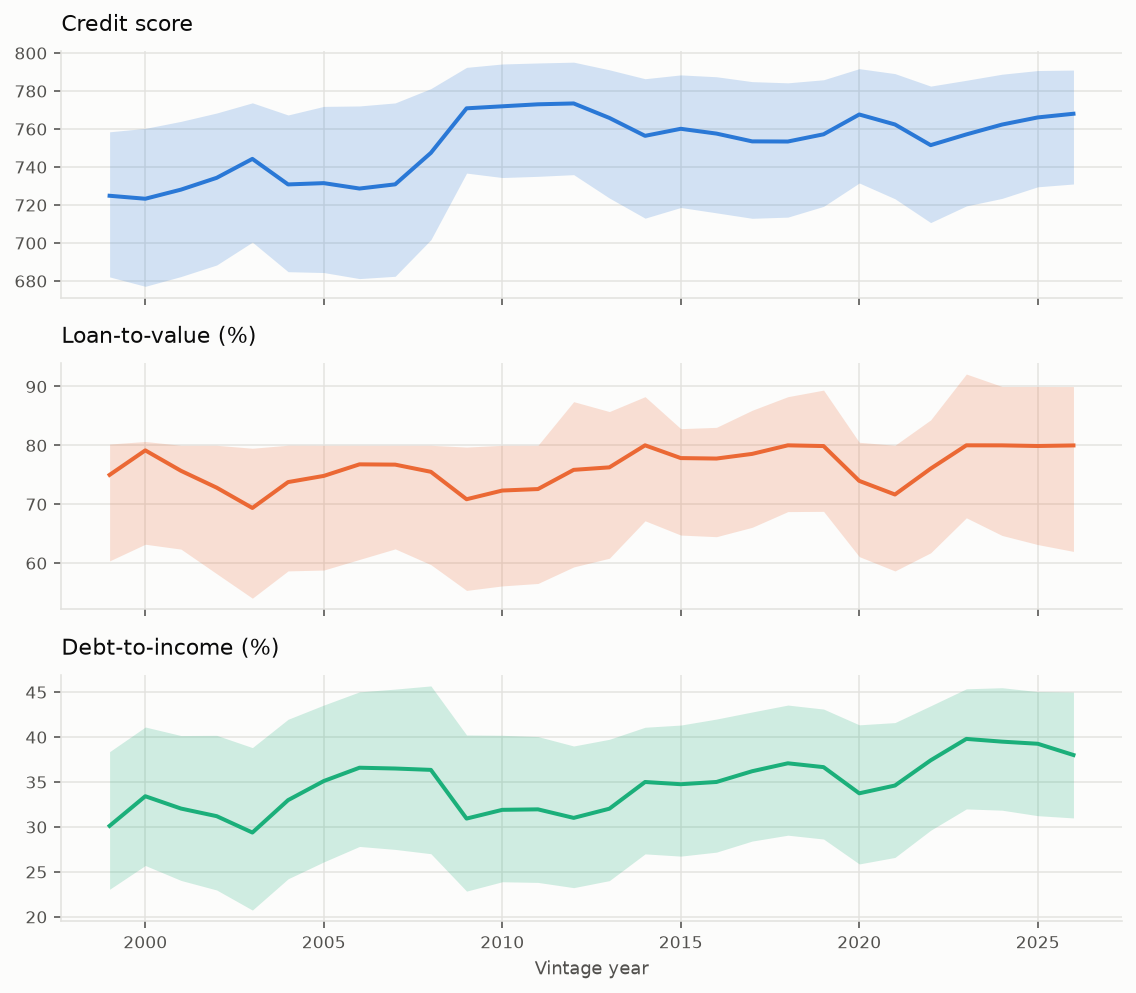

In [7]:
evolution = covariate_evolution()
charts.underwriting_over_time(evolution, figures / "underwriting_over_time.png")
Image(str(figures / "underwriting_over_time.png"))

In [8]:
evolution.set_index("year")[["score_q25", "score_q50", "score_q75", "ltv_q50", "dti_q50"]].round(
    1
).loc[[1999, 2006, 2012, 2021]]

,score_q25,score_q50,score_q75,ltv_q50,dti_q50
year,,,,,
1999,682.1,724.8,758.5,75.0,30.1
2006,681.2,728.6,772.1,76.8,36.6
2012,735.9,773.4,795.2,75.8,31.0
2021,723.2,762.4,789.1,71.6,34.6


## The economy the loans lived through

All four series are real, pulled from FRED with no API key. They are not background:
`unemp_gap`, `cltv_drift` and `nfci_lagged` are built from them, and they are what
let one model span 1999 to 2026 without a vintage dummy absorbing the very effects it
is meant to estimate.


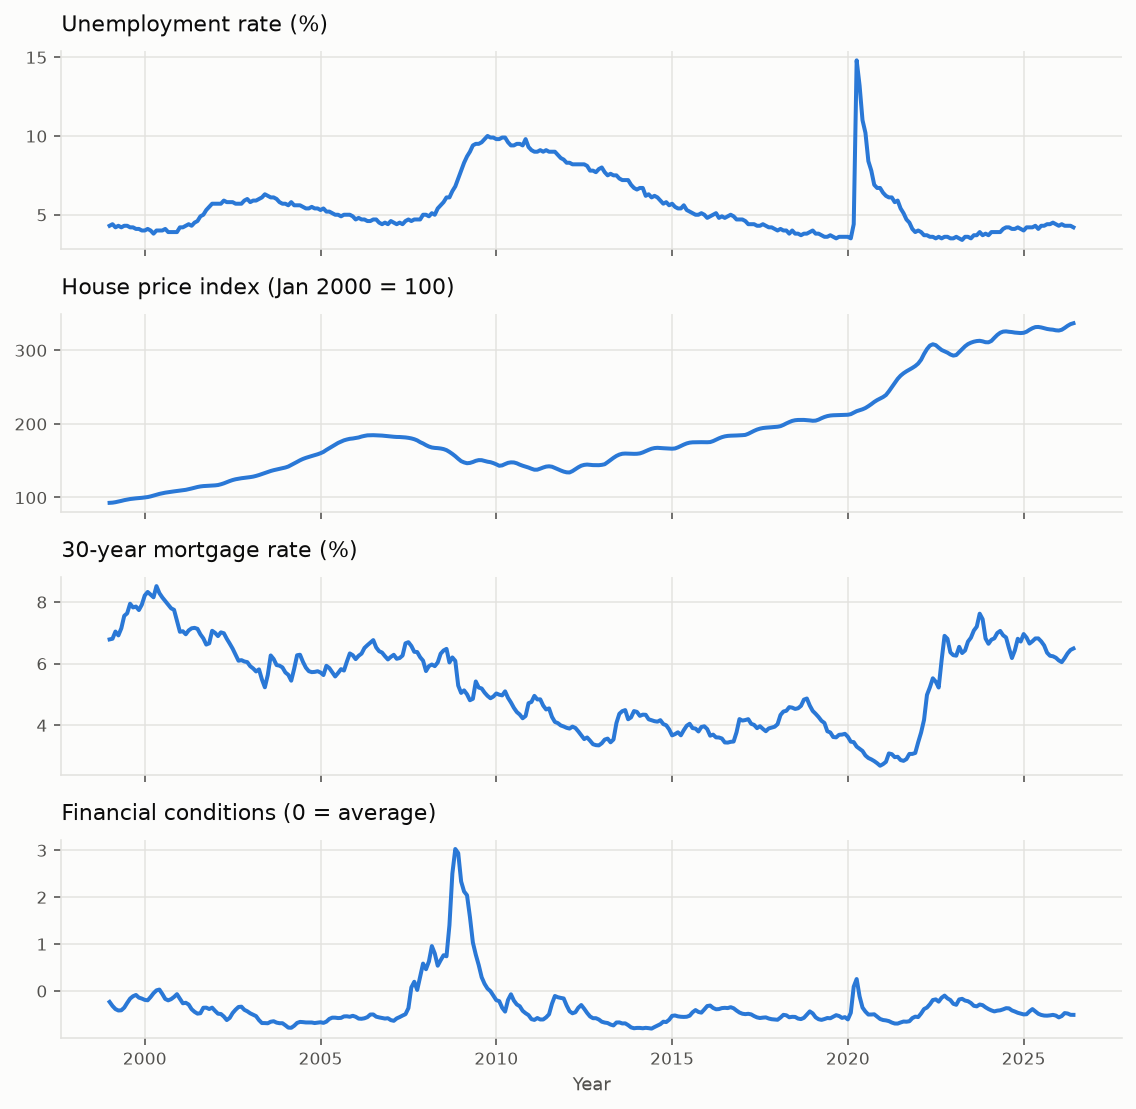

In [9]:
charts.macro_panel(macro, figures / "macro_panel.png")
Image(str(figures / "macro_panel.png"))

## Where to go next

- [`docs/portfolio.md`](../docs/portfolio.md) — this, written out with the numbers
- [`docs/data_preparation.md`](../docs/data_preparation.md) — how 40 GB becomes a fittable table
- [`docs/variable_selection.md`](../docs/variable_selection.md) — which covariates survive, and why
- [`02_lifetime_pd.ipynb`](02_lifetime_pd.ipynb) — the model itself
